In [1]:
print('Running imports...')
import os
from captum.attr import IntegratedGradients

os.environ["MKL_THREADING_LAYER"] = "GNU"

import torch # long
from lightning.pytorch import seed_everything
from torch import nn 

import xarray as xr
from tqdm import tqdm
import pandas as pd
import numpy as np 
import seaborn.objects as so
import argparse
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import seaborn as sns
import sys 
sys.path.append('/home/rogui7909/code/predict_rain_norway/predict_rain')
from ml_module_rain.models.individualblocks import DownBlock, ResidualDownBlock
from ml_module_rain.models.neuralnetworks import Encoder


Running imports...


In [2]:

import wandb
import torch # long
from lightning.pytorch import loggers, seed_everything
import xarray as xr
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
import argparse


from ml_module_rain.models.neuralnetworks import get_neural_network, register_shape_hooks
from ml_module_rain.data.datamodule import MyDataLoader
from ml_module_rain.models.lightning import ExtremeRainPredictor, AttributableTrainer
from ml_module_rain.models.losses import get_loss
from ml_module_rain.models.callbacks import LogF1Validation, get_checkpoint_callback
from ml_module_rain.utils.config import load_config
from pathlib import Path

In [3]:
config_path = '/home/rogui7909/code/predict_rain_norway/predict_rain/ml_module_rain/configs/config-defaults.yaml'

torch.set_float32_matmul_precision('medium')
seed_everything(42, workers=True)
init_config = load_config(config_path)
wandb_logger = loggers.WandbLogger(project="Predict-rain-WNorway_v6", 
                                save_dir="/Data/gfi/users/rogui7909/wanbd_logs/",
                                dir="/Data/gfi/users/rogui7909/wanbd_logs/wandb",
                                config=init_config )

wandb_logger.experiment # Initialize wandb
config = wandb_logger.experiment.config
dataloader = MyDataLoader(config)
dataloader.print_infos()
NN = get_neural_network(config)


Seed set to 42
wandb: Currently logged in as: rguilcas (rguilcas-university-of-bergen) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


Data ready:
    Image size: 16380 (182x90)
    Input variables: u850, v850, msl, z500
    21728 samples in train
    4656 samples in validation
    4657 samples in test
    7 Predicted timesteps for future rainfall
    Prediction type: boolean_smooth_regional
    What quantile is considered extreme: 95th of all days
torch.Size([1, 64, 3, 6])


In [ ]:
callbacks=[EarlyStopping(monitor="val/loss", mode="min"), 
            get_checkpoint_callback(wandb_logger),
        #    LogF1Validation(num_timesteps=config['num_timesteps_predicted']),
            ]
trainer = AttributableTrainer(limit_train_batches=100, 
                            max_epochs=config['num_epochs'], 
                            logger=wandb_logger, 
                            log_every_n_steps=1, default_root_dir="/Data/gfi/users/rogui7909/lightning_checkpoint/",
                            callbacks=callbacks, deterministic=True,
                            accelerator="cpu", devices=1)

loss = get_loss(config)
lightning_model = ExtremeRainPredictor(NN, 
                        learning_rate=config['learning_rate'], 
                        lr_scheduler =config['lr_scheduler'],
                        loss_fn = loss,
                        init_config=init_config)
trainer.fit(lightning_model,dataloader.train_loader, dataloader.val_loader)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:658: Checkpoint directory /felles_gfi/felles_gfi_users/rogui7909/data/NN_outputs/checkpoints exists and is not empty.

  | Name    | Type                         | Params | Mode 
-----------------------------------------------------------------
0 | model   | CNN_MLP                      | 222 K  | train
1 | loss_fn | BCEWithLogitsHorizonWeighted | 0      | train
-----------------------------------------------------------------
222 K     Trainable params
0         Non-trainable params
222 K     Total params
0.891     Total estimated model params size (MB)
68        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [5]:
dataloader.ds_train

<xarray.Dataset> Size: 30GB
Dimensions:    (longitude: 191, var_name: 4, time: 21728, latitude: 99,
                timestep: 7)
Coordinates:
  * longitude  (longitude) float64 2kB -128.0 -127.0 -126.0 ... 51.0 52.0 53.0
  * var_name   (var_name) <U5 80B 'u850' 'v850' 'msl' 'z500'
  * time       (time) datetime64[ns] 174kB 1947-11-02 1941-10-02 ... 1983-03-31
  * latitude   (latitude) float64 792B 0.0 1.0 2.0 3.0 ... 86.0 87.0 88.0 89.0
Dimensions without coordinates: timestep
Data variables:
    features   (time, var_name, latitude, longitude) float32 7GB -0.3323 ... ...
    targets    (time, timestep) float64 1MB 0.0 0.2211 1.0 0.0 ... 0.0 0.0 0.0
    rain       (time, latitude, longitude, timestep) float64 23GB nan ... nan

In [ ]:
NN.linear_size
# NN(dataloader.train_loader.dataset[0][0])

1152

In [ ]:
import torch
from ml_module_rain.models.individualblocks import  MLP, DownBlock, ResidualDownBlock, ContextBlock, GlobalAvgPool

def get_neural_network(config):
    if config['split_MLP_head_per_horizon']:
        if config.get('MLP_multihead_v2', False):
            NN_class = CNN_MLP_multiheads_v2
        else:
            NN_class = CNN_MLP_multiheads
    else:
        NN_class = CNN_MLP
    NN = NN_class(feature_height=config['feature_height'], 
             feature_width=config['feature_width'],
             input_channels=config['num_channels'],
             output_neurons=config['num_classes'],
             CNN_number_of_layers=config['num_conv_layer'],
             CNN_output_channels_first_layer=4,
             CNN_downsample_mode = config['CNN_downsample_mode'],
             CNN_conv_multiple = config['CNN_conv_multiple'],
             MLP_hidden_layers_neuron_number =  config['MLP_hidden_layers_neuron_number'], 
             dropout_MLP =config['dropout_MLP'],
             use_residuals=config['use_skip_connections'],
             activation_function=config['activation_function'],
             
                )
    return NN





class CNN_MLP(nn.Module):
    def __init__(self, 
                 feature_height, 
                 feature_width,
                 input_channels,
                 output_neurons,
                 CNN_number_of_layers=3,
                 CNN_output_channels_first_layer=16,
                 CNN_channels_increase_per_layer=2,
                 CNN_downsample_mode = 'strideconv',
                 CNN_conv_multiple = 'double',
                 MLP_hidden_layers_neuron_number = [128,512,512,128],
                 dropout_MLP = 0.1,
                 use_residuals=True,
                 activation_function = 'ReLU',
                 CNN_use_bn = True,
                 CNN_p_dropout =0.2
                 ):
        super(CNN_MLP, self).__init__()
        self.feature_height = feature_height
        self.feature_width = feature_width
        self.activation_function = activation_function
        self.CNN = Encoder(input_channels = input_channels, 
                           num_layers=CNN_number_of_layers, 
                           output_channels_first_layer=CNN_output_channels_first_layer,
                           channels_increase_per_layer=CNN_channels_increase_per_layer,
                           downsample_mode=CNN_downsample_mode,    # str or list[str]
                           conv_multiple=CNN_conv_multiple,   
                           use_residuals=use_residuals,
                           use_bn=CNN_use_bn,
                           p_dropout=CNN_p_dropout,
                           activation_function=self.activation_function)
        with torch.no_grad():
            dummy_input = torch.zeros(1, input_channels, feature_height, feature_width)
            cnn_output = self.CNN(dummy_input)
            print(cnn_output.shape)
            linear_size = cnn_output.view(1, -1).shape[1]
        
        self.linear_size = linear_size
        self.MLP = MLP(self.linear_size, 
                       output_neurons,
                       hidden_layers_neuron_number = MLP_hidden_layers_neuron_number,
                       dropout = dropout_MLP,
                       activation_function=self.activation_function
                      )
    def forward(self, x):
        x = self.CNN(x)
        x = x.view(-1, self.linear_size)
        x = self.MLP(x)
        return x

class CNN_MLP_multiheads(nn.Module):
    def __init__(self, 
                 feature_height, 
                 feature_width,
                 input_channels,
                 output_neurons,  # should now be number of horizons, e.g., 7
                 CNN_number_of_layers=3,
                 CNN_output_channels_first_layer=16,
                 CNN_channels_increase_per_layer=2,
                 CNN_downsample_mode = 'strideconv',
                 CNN_conv_multiple = 'double',
                 MLP_hidden_layers_neuron_number=[128,512,512,128],
                 dropout_MLP=0.1,
                 use_residuals=True,
                 activation_function='ReLU',
                 CNN_use_bn = True,
                 CNN_p_dropout =0.2,
                ):
        super(CNN_MLP_multiheads, self).__init__()
        self.feature_height = feature_height
        self.feature_width = feature_width
        self.activation_function = activation_function
        self.num_horizons = output_neurons  # <-- treat "classes" as "horizons"

        # Shared CNN backbone
        self.CNN = Encoder(
            input_channels=input_channels, 
            num_layers=CNN_number_of_layers, 
            output_channels_first_layer=CNN_output_channels_first_layer,
            channels_increase_per_layer=CNN_channels_increase_per_layer,
            downsample_mode=CNN_downsample_mode,    # str or list[str]
            conv_multiple=CNN_conv_multiple,
            use_residuals=use_residuals,
            use_bn=CNN_use_bn,
            p_dropout=CNN_p_dropout,
            activation_function=self.activation_function
        )

        # Figure out backbone output size
        with torch.no_grad():
            dummy_input = torch.zeros(1, input_channels, feature_height, feature_width)
            cnn_output = self.CNN(dummy_input)
            linear_size = cnn_output.view(1, -1).shape[1]
        self.linear_size = linear_size

        # One MLP head per horizon
        self.heads = nn.ModuleList([
            MLP(
                input_neurons=self.linear_size,
                output_neurons=1,  # 1 logit per horizon
                hidden_layers_neuron_number=MLP_hidden_layers_neuron_number,
                dropout=dropout_MLP,
                activation_function=self.activation_function
            )
            for _ in range(self.num_horizons)
        ])

    def forward(self, x):
        feats = self.CNN(x)
        feats = feats.view(-1, self.linear_size)

        # Collect logits from each horizon head
        logits = [head(feats) for head in self.heads]  # list of (B, 1)
        logits = torch.cat(logits, dim=1)  # shape: (B, num_horizons)

        return logits

In [37]:
dataloader.ds_train.isel(time=0).latitude

<xarray.DataArray 'latitude' (latitude: 99)> Size: 792B
array([ 0.  ,  1.  ,  2.  ,  3.  ,  4.  ,  5.  ,  6.  ,  7.  ,  8.  ,  9.  ,
       10.  , 11.  , 12.  , 13.  , 14.  , 15.  , 16.  , 17.  , 18.  , 19.  ,
       20.  , 21.  , 22.  , 23.  , 24.  , 25.  , 26.  , 27.  , 28.  , 29.  ,
       30.  , 31.  , 32.  , 33.  , 34.  , 35.  , 36.  , 37.  , 38.  , 39.  ,
       40.  , 41.  , 42.  , 43.  , 44.  , 45.  , 46.  , 47.  , 48.  , 49.  ,
       50.  , 51.  , 52.  , 53.  , 54.  , 55.  , 56.  , 57.  , 58.  , 59.  ,
       59.5 , 59.75, 60.  , 60.25, 60.5 , 60.75, 61.  , 61.25, 61.5 , 61.75,
       62.  , 62.25, 63.  , 64.  , 65.  , 66.  , 67.  , 68.  , 69.  , 70.  ,
       71.  , 72.  , 73.  , 74.  , 75.  , 76.  , 77.  , 78.  , 79.  , 80.  ,
       81.  , 82.  , 83.  , 84.  , 85.  , 86.  , 87.  , 88.  , 89.  ])
Coordinates:
    time      datetime64[ns] 8B 1947-11-02
  * latitude  (latitude) float64 792B 0.0 1.0 2.0 3.0 ... 86.0 87.0 88.0 89.0

In [35]:
X.shape 
# NN.CNN(X).shape

torch.Size([256, 4, 99, 191])

In [30]:
NN = get_neural_network(config)
# X = dataloader.train_loader.dataset[0][0]
# NN.CNN(X).shape
# 64*4*6

torch.Size([1, 64, 3, 6])


In [ ]:
393216/115

340.7417677642981

In [4]:
lightning_model.eval()
lightning_model.model.eval()
with torch.no_grad():
    trainer.test(lightning_model, dataloaders=dataloader.val_loader)
wandb.finish()

/Data/gfi/users/rogui7909/virtual_envs/ml-env/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/loss         │    1.0325366150113107     │
└───────────────────────────┴───────────────────────────┘

epoch,▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇█████
test/loss,▁
train/loss,█▇▅▅▄▃▄▃▃▄▃▃▃▃▃▂▂▃▃▃▂▂▂▃▃▃▃▁▂▂▂▂▂▁▂▁▂▁▃▂
trainer/global_step,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇█████
val/loss,█▆▅▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,53
test/loss,1.03254
train/loss,0.89275
trainer/global_step,2226
val/loss,1.03254


In [ ]:
callbacks=[EarlyStopping(monitor="val/loss", mode="min"), 
               get_checkpoint_callback(wandb_logger),
            #    LogF1Validation(num_timesteps=config['num_timesteps_predicted'],
            #                    target_value=1, number_of_classes=1),
            ]
trainer = AttributableTrainer(limit_train_batches=100, 
                            max_epochs=config['num_epochs'], 
                            logger=wandb_logger, 
                            log_every_n_steps=1, default_root_dir="/Data/gfi/users/rogui7909/lightning_checkpoint/",
                            callbacks=callbacks, deterministic=True,
                            accelerator="cpu", devices=1)

loss = get_loss(config['loss_function'], timesteps = config['num_timesteps_predicted'])
lightning_model = ExtremeRainPredictor(NN, 
                        learning_rate=config['learning_rate'], 
                        lr_scheduler =config['lr_scheduler'],
                        loss_fn = loss,
                        init_config=init_config)
trainer.fit(lightning_model,dataloader.train_loader, dataloader.val_loader)
lightning_model.eval()
lightning_model.model.eval()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name    | Type              | Params | Mode 
------------------------------------------------------
0 | model   | CNN_MLP           | 871 K  | eval 
1 | loss_fn | BCEWithLogitsLoss | 0      | train
------------------------------------------------------
871 K     Trainable params
0         Non-trainable params
871 K     Total params
3.485     Total estimated model params size (MB)
1         Modules in train mode
87        Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

CNN_MLP(
  (CNN): Encoder(
    (convblock0): ResidualBlock(
      (main): ConvolutionBlock(
        (downsample_block): DownsampleDoubleConv(
          (conv1): Conv2d(5, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (conv2): Conv2d(4, 4, kernel_size=(2, 2), stride=(2, 2))
        )
        (activation_function): ReLU()
        (batch_norm): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (dropout): Dropout2d(p=0.4, inplace=False)
      )
      (skip_connection): Conv2d(5, 4, kernel_size=(1, 1), stride=(1, 1))
      (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
      (activation): ReLU()
    )
    (convblock1): ResidualBlock(
      (main): ConvolutionBlock(
        (downsample_block): DownsampleDoubleConv(
          (conv1): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (conv2): Conv2d(8, 8, kernel_size=(2, 2), stride=(2, 2))
        )
        (activation_function): ReLU()
        (batch_norm):

In [17]:
y_validation = torch.stack(lightning_model.targets_validation)#.cpu().numpy()
y_scores = torch.stack(lightning_model.predictions_validation).view(-1, 1,1).cpu()
        


TypeError: stack(): argument 'tensors' (position 1) must be tuple of Tensors, not numpy.ndarray

In [3]:
torch.set_float32_matmul_precision('medium')
seed_everything(42, workers=True)
wandb_logger = loggers.WandbLogger(project="Predict-rain-WNorway_v5", 
                                save_dir="/Data/gfi/users/rogui7909/wanbd_logs/",
                                dir="/Data/gfi/users/rogui7909/wanbd_logs/wandb", )

wandb_logger.experiment # Initialize wandb
loader = MyDataLoader(wandb_logger)

# callbacks=[EarlyStopping(monitor="val/loss", mode="min"), LogF1Validation()]
# trainer = AttributableTrainer(limit_train_batches=100, 
#                             max_epochs=wandb_logger.experiment.config['num_epochs'], 
#                             logger=wandb_logger, 
#                             log_every_n_steps=1, default_root_dir="/Data/gfi/users/rogui7909/lightning_checkpoint/",
#                             callbacks=callbacks, deterministic=True,
#                             accelerator="gpu", devices=1,)
# match wandb_logger.experiment.config['CNN_layer_module']:
#     case 'ConvLayerStride1_ConvLayerStride2':
#         CNN_module = ConvLayerStride1_ConvLayerStride2
#     case 'ConvLayerStride1MaxPool':
#         CNN_module = ConvLayerStride1MaxPool
#     case 'ConvLayerStride2NoMaxPool':
#         CNN_module = ConvLayerStride2NoMaxPool
        
# NN = CNN_MLP(feature_height=loader.feature_height, 
#             feature_width=loader.feature_width,
#             input_channels=loader.config['num_channels'],
#             output_neurons=loader.config['num_classes'],
#             CNN_number_of_layers=loader.config['num_conv_layer'],
#             CNN_base_module = CNN_module,
#             MLP_hidden_layers_neuron_number = wandb_logger.experiment.config['MLP_hidden_layers_neuron_number'], 
#             use_residual = wandb_logger.experiment.config['use_skip_connections']
#             )
# loss = get_loss(wandb_logger.experiment.config['loss_function'], timesteps = wandb_logger.experiment.config['num_timesteps_predicted'])
# # loss = MultiCrossEntropyLoss()
# model = ExtremeRainPredictor(NN, 
#                         learning_rate=wandb_logger.experiment.config['learning_rate'], 
#                         lr_scheduler =wandb_logger.experiment.config['lr_scheduler'],
#                         loss_fn = loss)
# trainer.fit(model, loader.train_loader, loader.val_loader)
# model.eval()
# with torch.no_grad():
#     trainer.test(model, dataloaders=loader.val_loader)

# loader.attribute_integrated_gradients(model, loader.ds_val, model.predictions_test, model.targets_test)
# plot1 = plot_mean_attributions(loader.ds_attribution)
# wandb.log({"attributions/mean_attribution_plot": wandb.Image(plot1.fig)})
# plot2 = plot_top1pct_pixels(loader.ds_attribution)
# wandb.log({"attributions/top1pct_attributions": wandb.Image(plot2.fig)})

Seed set to 42
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: rguilcas (rguilcas-university-of-bergen) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
/Scientific_software/software/Anaconda3/2024.06-1/lib/python3.12/site-packages/pydantic/main.py:308: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(
/Scientific_software/software/Anaconda3/2024.06-1/lib/python3.12/site-packages/pydantic/main.py:308: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(


/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


In [5]:
loader.ds_test

<xarray.Dataset> Size: 38MB
Dimensions:    (longitude: 64, var_name: 1, time: 4602, latitude: 32,
                timestep: 4)
Coordinates:
  * longitude  (longitude) float64 512B -126.6 -123.8 -120.9 ... 47.81 50.62
  * var_name   (var_name) object 8B 'u850'
  * time       (time) datetime64[ns] 37kB 2009-05-24 2009-05-25 ... 2021-12-28
  * latitude   (latitude) float64 256B 1.406 4.219 7.031 ... 82.97 85.78 88.59
    mask_id    int64 8B 14
    quantile   float64 8B 0.9
Dimensions without coordinates: timestep
Data variables:
    features   (time, var_name, latitude, longitude) float32 38MB -0.1837 ......
    targets    (time, timestep) int64 147kB 1 1 1 1 1 1 1 1 ... 0 1 0 1 1 0 1 1
    rain       (time, timestep) float32 74kB 1.568 3.357 10.49 ... 19.48 14.14

In [6]:
loader.features

<xarray.DataArray 'data_normed' (time: 23008, var_name: 1, latitude: 32,
                                 longitude: 128)> Size: 377MB
array([[[[ 1.89175531e-01,  3.00392658e-01,  4.30193841e-01, ...,
          -2.70935912e-02,  6.49169534e-02,  1.07403278e-01],
         [-2.84841895e-01, -7.09698051e-02,  1.90277725e-01, ...,
          -5.39951921e-01, -4.67195839e-01, -3.87506157e-01],
         [-1.68862149e-01, -2.36258879e-01, -1.06715836e-01, ...,
          -3.74857575e-01, -1.64369941e-01, -7.12016672e-02],
         ...,
         [ 1.86908424e+00,  1.74919665e+00,  1.62729502e+00, ...,
           2.15977669e+00,  2.08560467e+00,  1.98394418e+00],
         [ 9.78790402e-01,  8.33104014e-01,  6.96852267e-01, ...,
           1.44807243e+00,  1.28826284e+00,  1.13136923e+00],
         [-1.70076981e-01, -1.96193367e-01, -2.18015254e-01, ...,
          -5.99161834e-02, -1.02179334e-01, -1.38911545e-01]]],


       [[[ 7.59050906e-01,  9.60094869e-01,  8.75320435e-01, ...,
           2.44886428e-02,  3.33003938e-01,  5.36309302e-01],
         [ 2.78662890e-01,  5.17013848e-01,  6.37393117e-01, ...,
          -4.58767742e-01, -3.15448821e-01, -4.44241762e-02],
         [-2.04498507e-02, -1.20008737e-03,  1.46340787e-01, ...,
...
         [-4.97844279e-01, -5.32556236e-01, -5.55191755e-01, ...,
          -3.16877931e-01, -3.88859779e-01, -4.49395508e-01],
         [-1.46203786e-02, -1.26550660e-01, -2.36433044e-01, ...,
           3.51285636e-01,  2.24231929e-01,  1.01909094e-01]]],


       [[[ 8.13021481e-01,  9.87691402e-01,  1.10824203e+00, ...,
           5.43216586e-01,  5.71195126e-01,  5.02174497e-01],
         [ 8.36786270e-01,  1.21340775e+00,  1.42240167e+00, ...,
           1.10187605e-01,  4.00878489e-01,  5.36099195e-01],
         [ 1.14121807e+00,  1.32254815e+00,  1.53656864e+00, ...,
           2.31249392e-01,  5.36255717e-01,  8.25047493e-01],
         ...,
         [-1.21119477e-01, -2.49769151e-01, -3.47115755e-01, ...,
           3.74057710e-01,  2.06162468e-01,  3.65592800e-02],
         [ 3.47646773e-01,  1.99135855e-01,  6.66256845e-02, ...,
           7.34046161e-01,  6.26786947e-01,  4.96491075e-01],
         [ 4.31215048e-01,  3.87266248e-01,  3.39501649e-01, ...,
           5.45977771e-01,  5.11326253e-01,  4.72712100e-01]]]],
      dtype=float32)
Coordinates:
  * longitude  (longitude) float64 1kB -180.0 -177.2 -174.4 ... 174.4 177.2
  * var_name   (var_name) object 8B 'u850'
  * time       (time) datetime64[ns] 184kB 1959-01-01 1959-01-02 ... 2021-12-28
  * latitude   (latitude) float64 256B 1.406 4.219 7.031 ... 82.97 85.78 88.59

In [12]:
import cartopy.crs as ccrs

AttributeError: QuadMesh.set() got an unexpected keyword argument 'dpi'

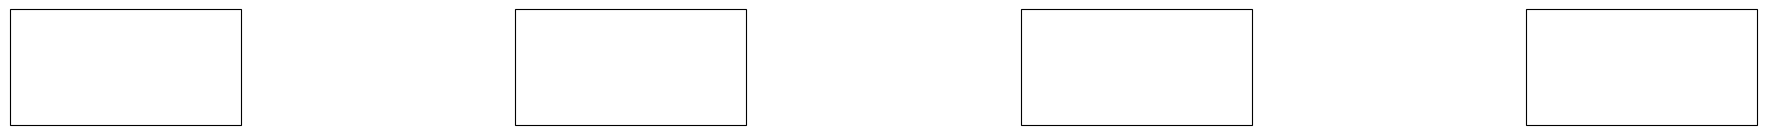

In [13]:
plot1 = plot_mean_attributions(loader.ds_attribution)
# wandb.log({"attributions/mean_attribution_plot": wandb.Image(plot1.fig)})
# plot2 = plot_top1pct_pixels(loader.ds_attribution)
# wandb.log({"attributions/top1pct_attributions": wandb.Image(plot2.fig)})

# wandb.finish()

# ds_attrs.attributions


In [ ]:
# ds_features = loader.ds_val
# predictions = model.predictions_test
# targets = model.targets_test

# ds_predictions = xr.DataArray(predictions, dims=['time','timestep'], coords = dict(time=ds_features.time[:predictions.shape[0]], timestep=range(1,5)))
# ds_targets = xr.DataArray(targets, dims=['time','timestep'], coords = dict(time=ds_features.time[:targets.shape[0]], timestep=range(1,5)))

# ds_results = xr.Dataset(dict(predictions=ds_predictions, targets=ds_targets))                             

# series_targets = ds_targets.to_series()
# series_predictions = ds_predictions.to_series()

# all_preds = ((series_predictions == series_targets)&(series_targets==2)).reset_index()
# all_preds.columns = ['time_of_prediction','timestep','TP_extreme']
# all_preds['time_of_event'] = all_preds.time_of_prediction + all_preds.timestep*pd.Timedelta(1,'D')
# extreme_events_predictions = all_preds.groupby('time_of_event').TP_extreme.sum()

# all_targets = ((series_targets==2)).reset_index()
# all_targets.columns = ['time_of_prediction','timestep','extreme']
# all_targets['time_of_event'] = all_targets.time_of_prediction + all_targets.timestep*pd.Timedelta(1,'D')
# extreme_events = all_targets.groupby('time_of_event').extreme.sum()


# extreme_events_predictions = extreme_events_predictions.loc[extreme_events[extreme_events==4].index]

# time_TP_extreme = extreme_events_predictions.loc[extreme_events_predictions==4].index

# steps = 4

# start_times = time_TP_extreme -  pd.Timedelta(steps-1,'D')




In [ ]:
# start_times

DatetimeIndex(['1997-02-05', '1997-02-27', '1997-09-06', '1997-09-14',
               '1998-02-09', '1998-02-25', '1998-10-13', '1998-10-21',
               '1998-12-13', '1998-12-15', '1998-12-23', '1999-01-14',
               '1999-02-13', '1999-10-31', '1999-11-23', '1999-12-05',
               '1999-12-22', '2000-02-04', '2000-02-10', '2000-06-12',
               '2000-09-06', '2000-09-07', '2001-10-01', '2001-10-10',
               '2001-11-01', '2001-11-02', '2002-03-03', '2002-08-29',
               '2003-01-12', '2003-01-13', '2003-09-20', '2003-09-23',
               '2003-12-23', '2004-09-11', '2004-09-12', '2004-09-25',
               '2004-10-02', '2004-11-10', '2004-12-03', '2004-12-05',
               '2004-12-28', '2005-01-02', '2005-01-04', '2005-01-05',
               '2005-01-06', '2005-08-27', '2005-09-18', '2005-10-07',
               '2005-11-08', '2005-11-10', '2006-11-12', '2006-11-29',
               '2006-12-09', '2006-12-11', '2006-12-12', '2007-01-07',
      

In [ ]:
# target

In [ ]:
# ds_test_extract

<xarray.Dataset> Size: 67kB
Dimensions:    (longitude: 128, var_name: 1, time: 4, latitude: 32, timestep: 4)
Coordinates:
  * longitude  (longitude) float64 1kB -180.0 -177.2 -174.4 ... 174.4 177.2
  * var_name   (var_name) object 8B 'u850'
  * time       (time) datetime64[ns] 32B 1997-02-05 1997-02-06 ... 1997-02-08
  * latitude   (latitude) float64 256B 1.406 4.219 7.031 ... 82.97 85.78 88.59
    mask_id    int64 8B 14
    quantile   float64 8B 0.9
Dimensions without coordinates: timestep
Data variables:
    features   (time, var_name, latitude, longitude) float32 66kB -0.5721 ......
    targets    (time, timestep) int64 128B 1 1 2 1 1 2 1 2 2 1 2 1 1 2 1 1
    rain       (time, timestep) float32 64B 7.095 17.72 23.23 ... 15.93 17.33

In [106]:
from tqdm.notebook import tqdm


from captum.attr import IntegratedGradients
method = IntegratedGradients(model.model)
all_multi_attrs = []
all_multi_sens = []

for k in tqdm(range(len(time_TP_extreme))):
    start = start_times[k].strftime("%Y-%m-%d %H:%M:%S")
    end = time_TP_extreme[k].strftime("%Y-%m-%d %H:%M:%S")
    # print(start,end)
    ds_test_extract = loader.ds_val.sel(time=slice(start ,end))
    tensor_in = torch.Tensor(ds_test_extract.features.values)
    tensor_out = torch.Tensor(ds_test_extract.targets.values)
    attrs = method.attribute(tensor_in, baselines=torch.Tensor([0]),target=[3*(steps-k)-1 for k in range(steps)]) 
    da_attrs = xr.DataArray(attrs, dims = ['timestep','var_name','latitude','longitude'], 
                            coords= dict(timestep=np.arange(1,steps+1),var_name=ds_test_extract.var_name, latitude=ds_test_extract.latitude, longitude=ds_test_extract.longitude))
    all_multi_attrs.append(da_attrs.assign_coords(time=time_TP_extreme[k]))
    sens = da_attrs/ds_test_extract.features.rename(time='timestep').assign_coords(timestep=da_attrs.timestep)
    all_multi_sens.append(sens.assign_coords(time=time_TP_extreme[k]))
ds_attributions = xr.concat(all_multi_attrs, dim='time')
ds_sens = xr.concat(all_multi_sens, dim='time')
final_ds = xr.Dataset(dict(attributions = ds_attributions, sensitivity=ds_sens))


  0%|          | 0/65 [00:00<?, ?it/s]

In [107]:
final_ds

<xarray.Dataset> Size: 9MB
Dimensions:       (timestep: 4, var_name: 1, latitude: 32, longitude: 128,
                   time: 65)
Coordinates:
  * timestep      (timestep) int64 32B 1 2 3 4
  * var_name      (var_name) object 8B 'u850'
  * latitude      (latitude) float64 256B 1.406 4.219 7.031 ... 85.78 88.59
  * longitude     (longitude) float64 1kB -180.0 -177.2 -174.4 ... 174.4 177.2
  * time          (time) datetime64[ns] 520B 1997-02-08 ... 2007-12-28
    mask_id       int64 8B 14
    quantile      float64 8B 0.9
Data variables:
    attributions  (time, timestep, var_name, latitude, longitude) float32 4MB ...
    sensitivity   (time, timestep, var_name, latitude, longitude) float32 4MB ...

<Axes: ylabel='Frequency'>

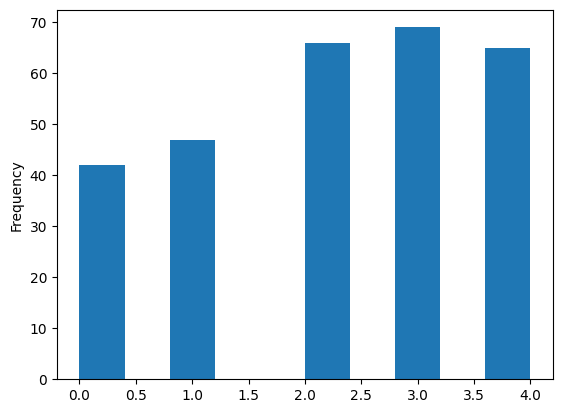

In [ ]:
.plot.hist()

<Axes: ylabel='Frequency'>

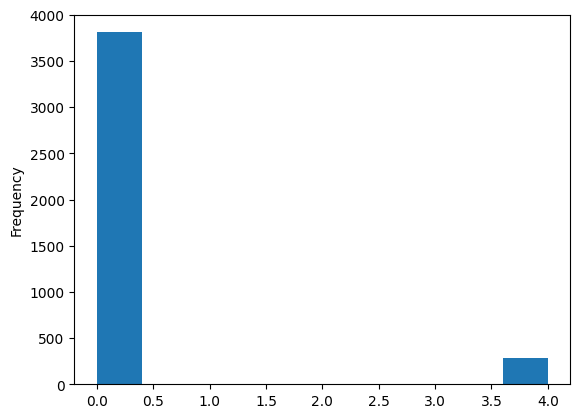

In [71]:
extreme_events.plot.hist()

In [ ]:
df_=pd.DataFrame(dict(pred=preds.to_series(), targets=targets.to_series()))
df_['pred_time'] = (df_.index.get_level_values(0)+pd.Timedelta(1,'D')*df_.index.get_level_values(1)).values

times = df_.query("targets==2 & pred==2").groupby('pred_time').count().pred.sort_values()
events_predicted = times.loc[times>3].index
steps = 4
start_times = events_predicted -  pd.Timedelta(steps-1,'D')
print("Number of 4x events:",len(start_times))
num_extremes = df_.targets.loc[df_.targets==2].unstack().count(axis=1)
num_extremes_pred = df_.targets.where((df_.targets==2)&(df_.pred==2)).fillna(0).unstack().sum(axis=1)//2

pred_FP = df_.query("pred==2 & targets<2").groupby('pred_time').count().query("pred==4").index

start_times_FP = pred_FP - pd.Timedelta(steps-1,'D')

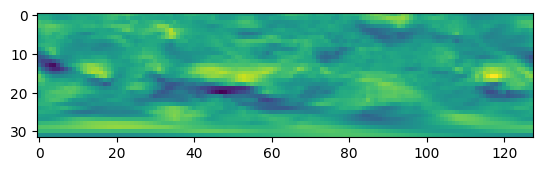

In [12]:
plt.imshow(test[0][0])

In [30]:
class ResidualBlock(nn.Module):
    def __init__(self, base_module, input_channels, output_channels):
        super(ResidualBlock, self).__init__()
        self.main = base_module(input_channels, output_channels)

        self.skip_connection = nn.Identity()
        if input_channels != output_channels:
            self.skip_connection = nn.Conv2d(input_channels, output_channels, kernel_size=1, stride=1)
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)

        self.activation = nn.ReLU()
    def forward(self, x):
        identity = self.skip_connection(x)
        identity = self.pool(identity)
        out = self.main(x)
        out += identity
        out = self.activation(out)
        return out

In [31]:
main

ConvLayerStride1MaxPool(
  (activation_function): ReLU()
  (conv_layer): Conv2d(5, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)

In [ ]:
in_ch = 5
out_ch = 6
main =  ConvLayerStrideNoMaxPool(in_ch,out_ch)
skip_connection = nn.Identity()
if in_ch != out_ch:
    skip_connection = nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=1)
skip_connection
hasattr(main, "maxpool")


True

In [33]:
conv = ConvLayerStride2NoMaxPool(5,5)
res = ResidualBlock(ConvLayerStride2NoMaxPool, 5,5)
print(test.shape)
print(res(test).shape)

torch.Size([1, 5, 32, 128])
torch.Size([1, 5, 16, 64])


wandb: WARNING Fatal error while uploading data. Some run data will not be synced, but it will still be written to disk. Use `wandb sync` at the end of the run to try uploading.


In [ ]:
import torch.nn as nn
class ConvLayerStride1MaxPool(nn.Module):
    def __init__(self, 
                 input_channels, 
                 output_channels,
                 activation_function=nn.ReLU(),
                 size_conv_kernel=3
                 ):
        super(ConvLayerStride1MaxPool, self).__init__()
        self.input_channels = input_channels
        self.output_channels = output_channels
        self.activation_function = activation_function
        self.conv_layer = nn.Conv2d(self.input_channels, 
                                    self.output_channels, 
                                    kernel_size=size_conv_kernel, 
                                    stride=1, padding=(size_conv_kernel-1)//2)
        self.bn2 = nn.BatchNorm2d(output_channels)
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        output = self.conv_layer(x)
        output = self.bn2(output)
        output = self.maxpool(output)
        output = self.activation_function(output)
        return output

class ConvLayerStride1_ConvLayerStride2(nn.Module):
    def __init__(self, 
                 input_channels, 
                 output_channels,
                 activation_function=nn.ReLU(),
                 size_conv_kernel=3
                 ):
        super(ConvLayerStride1_ConvLayerStride2, self).__init__()
        self.input_channels = input_channels
        self.output_channels = output_channels
        self.activation_function = activation_function
        self.conv_layer1 = nn.Conv2d(self.input_channels, 
                                    self.output_channels, 
                                    kernel_size=size_conv_kernel, 
                                    stride=1, padding=(size_conv_kernel-1)//2)
        self.conv_layer2 = nn.Conv2d(self.output_channels, 
                                    self.output_channels, 
                                    kernel_size=2, 
                                    stride=2, padding=0)
        
        self.bn2 = nn.BatchNorm2d(output_channels)

    def forward(self, x):
        output = self.conv_layer1(x)
        output = self.conv_layer2(output)
        output = self.bn2(output)
        output = self.activation_function(output)
        return output
    
class ConvLayerStride2NoMaxPool(nn.Module):
    def __init__(self, 
                 input_channels, 
                 output_channels,
                 activation_function=nn.ReLU(),
                 size_conv_kernel=3
                 ):
        super(ConvLayerStride2NoMaxPool, self).__init__()
        self.input_channels = input_channels
        self.output_channels = output_channels
        self.activation_function = activation_function
        self.conv_layer = nn.Conv2d(self.input_channels, 
                                    self.output_channels, 
                                    kernel_size=size_conv_kernel, 
                                    stride=2, padding=(size_conv_kernel-1)//2)
        self.bn2 = nn.BatchNorm2d(output_channels)

    def forward(self, x):
        output = self.conv_layer(x)
        output = self.bn2(output)
        output = self.activation_function(output)
        return output


In [4]:
wandb_logger = loggers.WandbLogger(project="Predict-rain-WNorway_v5", 
                                    save_dir="/Data/gfi/users/rogui7909/wanbd_logs/",
                                    dir="/Data/gfi/users/rogui7909/wanbd_logs/wandb", )

wandb_logger.experiment # Initialize wandb

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: rguilcas (rguilcas-university-of-bergen) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
/Scientific_software/software/Anaconda3/2024.06-1/lib/python3.12/site-packages/pydantic/main.py:308: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(


/Scientific_software/software/Anaconda3/2024.06-1/lib/python3.12/site-packages/pydantic/main.py:308: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(


In [5]:
from src.data import MyDataLoader
from src.lightning import ExtremeRainPredictor, AttributableTrainer
from src.neuralnetworks import CNN_MLP
from src.losses import MultiCrossEntropyLoss
from src.callbacks import LogF1Validation

In [6]:
loader = MyDataLoader(wandb_logger)


/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/xarray/core/indexing.py:1679: PerformanceWarning: Slicing with an out-of-order index is generating 1387 times more chunks
  return self.array[key]


In [7]:
callbacks=[EarlyStopping(monitor="val/loss", mode="min"), LogF1Validation()]
trainer = AttributableTrainer(limit_train_batches=100, 
                              max_epochs=wandb_logger.experiment.config['num_epochs'], 
                              logger=wandb_logger, 
                              log_every_n_steps=1, default_root_dir="/Data/gfi/users/rogui7909/lightning_checkpoint/",
                              callbacks=callbacks, deterministic=True,
                              accelerator="gpu", devices=1,)

NN = CNN_MLP(feature_height=loader.feature_height, 
             feature_width=loader.feature_width,
             input_channels=loader.config['num_channels'],
             output_neurons=loader.config['num_classes'],
             CNN_number_of_layers=5,
             )

# Need to add to proba module


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [8]:


loss = MultiCrossEntropyLoss(timesteps = wandb_logger.experiment.config['num_timesteps_predicted'])


model = ExtremeRainPredictor(NN, 
                          learning_rate=wandb_logger.experiment.config['learning_rate'], 
                          lr_scheduler =wandb_logger.experiment.config['lr_scheduler'],
                          loss_fn = loss)

In [9]:
trainer.fit(model, loader.train_loader, loader.val_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type                  | Params | Mode 
----------------------------------------------------------
0 | model   | CNN_MLP               | 920 K  | train
1 | loss_fn | MultiCrossEntropyLoss | 0      | train
----------------------------------------------------------
920 K     Trainable params
0         Non-trainable params
920 K     Total params
3.682     Total estimated model params size (MB)
33        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=1` reached.


In [10]:
model.f1_validation

tensor(0.2141)

In [11]:
trainer

In [12]:
model.eval()
with torch.no_grad():
    trainer.test(model, dataloaders=loader.val_loader)
wandb.finish()

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/loss         │    1.0559817552566528     │
└───────────────────────────┴───────────────────────────┘

epoch,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█
test/loss,▁
train/loss,▇█▇▆▆▇▆▇▅▆▅▅▅▄▄▄▄▆▅▄▆▅▃▆▂▄▄▂▄▃▃▃▃▃▂▄▁▄▃▂
trainer/global_step,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇█████
val/f1_epoch,▁█
val/loss,▁
val/precision_epoch,▁█
val/recall_epoch,█▁
epoch,1
test/loss,1.05598
train/loss,1.05922


In [ ]:
# y_test = torch.stack(model.test_true_values)#.cpu().numpy()
y_test = torch.stack(model.test_true_values)#.cpu().numpy()
y_scores = torch.stack(model.test_pred).view(-1, wandb_logger.experiment.config['num_timesteps_predicted'], 3).cpu()
preds = torch.argmax(y_scores, dim=2)
targets=xr.DataArray(y_test.cpu().numpy(), dims=['time','timestep'], coords=dict(time=ds_test.time[:y_test.shape[0]], timestep=np.arange(y_scores.shape[1])))
preds=xr.DataArray(preds.cpu().numpy(), dims=['time','timestep'], coords=dict(time=ds_test.time[:y_test.shape[0]], timestep=np.arange(y_scores.shape[1])))
results = xr.Dataset(dict(targets=targets, preds=preds))
df_=pd.DataFrame(dict(pred=preds.to_series(), targets=targets.to_series()))
df_['pred_time'] = (df_.index.get_level_values(0)+pd.Timedelta(1,'D')*df_.index.get_level_values(1)).values

TypeError: stack(): argument 'tensors' (position 1) must be tuple of Tensors, not numpy.ndarray

In [113]:
import torch.nn as nn

class ConvLayerStride1MaxPool(nn.Module):
    def __init__(self, 
                 input_channels, 
                 output_channels,
                 activation_function=nn.ReLU(),
                 size_conv_kernel=3
                 ):
        super(ConvLayerStride1MaxPool, self).__init__()
        self.input_channels = input_channels
        self.output_channels = output_channels
        self.activation_function = activation_function
        self.conv_layer = nn.Conv2d(self.input_channels, 
                                    self.output_channels, 
                                    kernel_size=size_conv_kernel, 
                                    stride=1, padding=(size_conv_kernel-1)//2)
        self.bn2 = nn.BatchNorm2d(output_channels)
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        output = self.conv_layer(x)
        output = self.bn2(output)
        output = self.maxpool(output)
        output = self.activation_function(output)
        return output

class ConvLayerStride1_ConvLayerStride2(nn.Module):
    def __init__(self, 
                 input_channels, 
                 output_channels,
                 activation_function=nn.ReLU(),
                 size_conv_kernel=3
                 ):
        super(ConvLayerStride1_ConvLayerStride2, self).__init__()
        self.input_channels = input_channels
        self.output_channels = output_channels
        self.activation_function = activation_function
        self.conv_layer1 = nn.Conv2d(self.input_channels, 
                                    self.output_channels, 
                                    kernel_size=size_conv_kernel, 
                                    stride=1, padding=(size_conv_kernel-1)//2)
        self.conv_layer2 = nn.Conv2d(self.output_channels, 
                                    self.output_channels, 
                                    kernel_size=2, 
                                    stride=2, padding=0)
        
        self.bn2 = nn.BatchNorm2d(output_channels)

    def forward(self, x):
        output = self.conv_layer1(x)
        output = self.conv_layer2(output)
        output = self.bn2(output)
        output = self.activation_function(output)
        return output
    
class ConvLayerStride2NoMaxPool(nn.Module):
    def __init__(self, 
                 input_channels, 
                 output_channels,
                 activation_function=nn.ReLU(),
                 size_conv_kernel=3
                 ):
        super(ConvLayerStride2NoMaxPool, self).__init__()
        self.input_channels = input_channels
        self.output_channels = output_channels
        self.activation_function = activation_function
        self.conv_layer = nn.Conv2d(self.input_channels, 
                                    self.output_channels, 
                                    kernel_size=size_conv_kernel, 
                                    stride=2, padding=(size_conv_kernel-1)//2)
        self.bn2 = nn.BatchNorm2d(output_channels)

    def forward(self, x):
        output = self.conv_layer(x)
        output = self.bn2(output)
        output = self.activation_function(output)
        return output

class CNN(nn.Module):
    def __init__(self, 
                 input_channels, 
                 output_channels_first_layer=16,
                 channels_increase_per_layer=2,
                 base_module = ConvLayerStride1MaxPool,
                 num_layers=3,
                 activation_function=nn.ReLU(),
                 size_conv_kernel=3,
                 ):
        super(CNN, self).__init__()
        self.input_channels = input_channels
        self.num_layers = num_layers
        self.output_layers = [output_channels_first_layer*channels_increase_per_layer**layer for layer in range(num_layers)]
        self.convs = nn.ModuleList()
        self.activation_function = activation_function
        self.size_conv_kernel = size_conv_kernel
        for i in range(num_layers):
            conv = base_module(
                input_channels if i == 0 else self.output_layers[i-1],
                self.output_layers[i],
                activation_function=self.activation_function,
                size_conv_kernel=self.size_conv_kernel            
                )
            self.convs.append(conv)

    def forward(self, x):
        for conv in self.convs:
            x = conv(x)
        return x

class MLP(nn.Module):
    def __init__(self, 
                 input_neurons, 
                 output_neurons,
                 hidden_layers_neuron_number = [128,512,512,128],
                 ):
        super(MLP, self).__init__()
        self.input_neurons = input_neurons
        self.output_neurons = output_neurons
        self.neurons = [input_neurons] + hidden_layers_neuron_number + [output_neurons]
        self.layers = nn.ModuleList()
        for i in range(1,len(self.neurons)):
            layer = nn.Linear(self.neurons[i-1], self.neurons[i])
            self.layers.append(layer)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    

class CNN_MLP(nn.Module):
    def __init__(self, 
                 feature_height, 
                 feature_width,
                 input_channels,
                 output_neurons,
                 CNN_number_of_layers=3,
                 CNN_output_channels_first_layer=16,
                 CNN_channels_increase_per_layer=2,
                 CNN_base_module = ConvLayerStride1MaxPool,
                 CNN_activation_function=nn.ReLU(),
                 CNN_size_conv_kernel=3,
                 MLP_hidden_layers_neuron_number = [128,512,512,128],
                 ):
        super(CNN_MLP, self).__init__()
        self.feature_height = feature_height
        self.feature_width = feature_width
        self.CNN = CNN(input_channels = input_channels, 
                       num_layers=CNN_number_of_layers, 
                       output_channels_first_layer=CNN_output_channels_first_layer,
                       channels_increase_per_layer=CNN_channels_increase_per_layer,
                       base_module = CNN_base_module,
                       activation_function=CNN_activation_function,
                       size_conv_kernel=CNN_size_conv_kernel,)
        reduced_image_size = self.feature_height//(2**self.CNN.num_layers) * self.feature_width//(2**self.CNN.num_layers)
        last_out_layers = self.CNN.output_layers[-1]
        self.linear_size = reduced_image_size*last_out_layers
        self.MLP = MLP(self.linear_size, 
                       output_neurons,
                       hidden_layers_neuron_number = MLP_hidden_layers_neuron_number,
                      )
    def forward(self, x):
        x = self.CNN(x)
        x = x.view(-1, self.linear_size)
        x = self.MLP(x)
        return x

        
#         # x shape: (batch_size, seq_length, channels, height, width)
#         # Apply CNN to extract spatial features
#         self.conv_layer1 = nn.Sequential(
# #                                      nn.Conv2d(input_channels, 
# #                                      out_channels_conv1, 
# #                                      kernel_size=size_conv_kernel, 
# #                                      stride=1, padding=(size_conv_kernel-1)//2),
# #                             nn.MaxPool2d(kernel_size=2, stride=2),
# #                             nn.ReLU())
#         batch_size,  channels, height, width = x.size()
#         if self.number_conv_layers>0:
#             cnn_out = self.cnn(x)
#         else:
#             cnn_out = x
#         cnn_out = cnn_out.view(batch_size, -1)  # Shape: (batch_size, seq_length, features)
#         output = self.fc1(cnn_out)  # Shape: (batch_size, output_size)
#         output = self.fc2(output)
#         output = output.view(-1, self.num_timesteps, self.classes_per_timestep-1)
#         output = torch.sigmoid(output) 
#         X1 = output[:,:,0]
#         X2 = output[:,:,1]
#         P_norain = X1 
#         P_rain = (1-X1)*(1-X2)
#         P_extreme = (1-X1)*X2
#         output = torch.stack([P_norain, P_rain, P_extreme], dim=2)
#         return output.view(-1, self.num_timesteps*self.classes_per_timestep)



        
# class CNN(nn.Module):
#     def __init__(self, 
#                  input_channels, 
#                  image_size, 
#                  num_timesteps,
#                  number_conv_layers=4,
#                  size_conv_kernel=3,
#                  out_channels_conv1=12, 
#                  out_channel_factor_increase_per_layer = 2,
#                  ):
#         super(CNN_Model_2, self).__init__()
        
#         # CNN layers to extract spatial features
#         # self.sigmoid = sigmoid
#         # self.softmax = softmax
#         self.num_timesteps = num_timesteps
#         self.classes_per_timestep = 3
#         self.num_classes = self.num_timesteps*(self.classes_per_timestep-1)
#         self.number_conv_layers = number_conv_layers
#         self.conv_layer1 = nn.Sequential(
#                                      nn.Conv2d(input_channels, 
#                                      out_channels_conv1, 
#                                      kernel_size=size_conv_kernel, 
#                                      stride=1, padding=(size_conv_kernel-1)//2),
#                             nn.MaxPool2d(kernel_size=2, stride=2),
#                             nn.ReLU())
#         self.conv_layer2 = nn.Sequential(
#                                 nn.Conv2d(out_channels_conv1, 
#                                           out_channels_conv1*out_channel_factor_increase_per_layer, 
#                                           kernel_size=size_conv_kernel, 
#                                           stride=1, padding=(size_conv_kernel-1)//2),
#                                 nn.MaxPool2d(kernel_size=2, stride=2),
#                                 nn.ReLU())
#         self.conv_layer3 = nn.Sequential(
#                                 nn.Conv2d(out_channels_conv1*out_channel_factor_increase_per_layer, 
#                                           out_channels_conv1*out_channel_factor_increase_per_layer**2, 
#                                           kernel_size=size_conv_kernel, 
#                                           stride=1, padding=(size_conv_kernel-1)//2),
#                                 nn.MaxPool2d(kernel_size=2, stride=2),
#                                 nn.ReLU())
#         self.conv_layer4 = nn.Sequential(
#                                 nn.Conv2d(out_channels_conv1*out_channel_factor_increase_per_layer**2, 
#                                           out_channels_conv1*out_channel_factor_increase_per_layer**3, 
#                                           kernel_size=size_conv_kernel, 
#                                           stride=1, padding=(size_conv_kernel-1)//2),
#                                 nn.MaxPool2d(kernel_size=2, stride=2),
#                                 nn.ReLU())
#         self.conv_layer5 = nn.Sequential(
#                                 nn.Conv2d(out_channels_conv1*out_channel_factor_increase_per_layer**3, 
#                                           out_channels_conv1*out_channel_factor_increase_per_layer**4, 
#                                           kernel_size=size_conv_kernel, 
#                                           stride=1, padding=(size_conv_kernel-1)//2),
#                                 nn.MaxPool2d(kernel_size=2, stride=2),
#                                 nn.ReLU())
#         self.conv_layer6 = nn.Sequential(
#                                 nn.Conv2d(out_channels_conv1*out_channel_factor_increase_per_layer**4, 
#                                             out_channels_conv1*out_channel_factor_increase_per_layer**5, 
#                                             kernel_size=size_conv_kernel, 
#                                             stride=1, padding=1),
#                                 nn.MaxPool2d(kernel_size=(1,2), stride=2),
#                                 nn.ReLU())
        
#         if number_conv_layers == 1:
#             self.cnn = nn.Sequential(self.conv_layer1)
#         elif number_conv_layers == 2:
#             self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2)
#         elif number_conv_layers == 3:
#             self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2, self.conv_layer3)
#         elif number_conv_layers == 4:
#             self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2, self.conv_layer3, self.conv_layer4)
#         elif number_conv_layers == 5:
#             self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2, self.conv_layer3, self.conv_layer4, self.conv_layer5)
#         elif number_conv_layers == 6:
#             self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2, self.conv_layer3, self.conv_layer4, self.conv_layer5, self.conv_layer6)
        
#         max_pools = 4**(number_conv_layers)
#         self.output_cnn_channels  = out_channels_conv1*out_channel_factor_increase_per_layer**(number_conv_layers-1)
#         if self.number_conv_layers == 0:
#             self.linear_size = image_size 
#         else:
#             self.linear_size = image_size * self.output_cnn_channels // max_pools 
#         if self.number_conv_layers == 6:
#             self.linear_size = self.linear_size*2
#         if self.number_conv_layers == 0:
#             self.linear_size = image_size*2 
#         self.fc1 = nn.Linear(self.linear_size, 512)
#         self.fc2 = nn.Linear(512, self.num_classes)
    
#     def forward(self, x):
#         # x shape: (batch_size, seq_length, channels, height, width)
#         # Apply CNN to extract spatial features
#         batch_size,  channels, height, width = x.size()
#         if self.number_conv_layers>0:
#             cnn_out = self.cnn(x)
#         else:
#             cnn_out = x
#         cnn_out = cnn_out.view(batch_size, -1)  # Shape: (batch_size, seq_length, features)
#         output = self.fc1(cnn_out)  # Shape: (batch_size, output_size)
#         output = self.fc2(output)
#         output = output.view(-1, self.num_timesteps, self.classes_per_timestep-1)
#         output = torch.sigmoid(output) 
#         X1 = output[:,:,0]
#         X2 = output[:,:,1]
#         P_norain = X1 
#         P_rain = (1-X1)*(1-X2)
#         P_extreme = (1-X1)*X2
#         output = torch.stack([P_norain, P_rain, P_extreme], dim=2)
#         return output.view(-1, self.num_timesteps*self.classes_per_timestep)
        



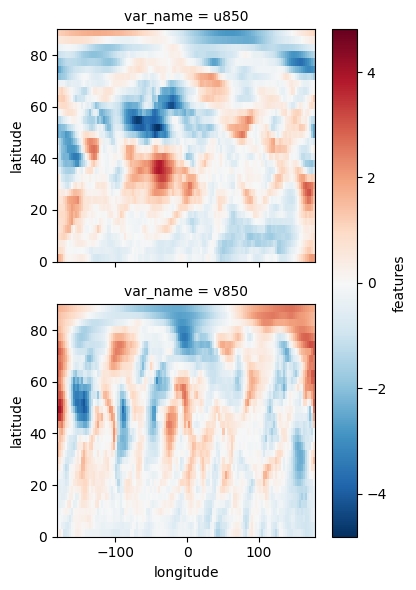

In [23]:
loader.ds_train.sel(time='1969-01-10').features.plot( row='var_name')

In [12]:
wandb.finish()

In [95]:
ds = loader.get_ds_train()

/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/xarray/core/indexing.py:1679: PerformanceWarning: Slicing with an out-of-order index is generating 1377 times more chunks
  return self.array[key]


In [ ]:
import dask


In [136]:
ds_out

<xarray.Dataset> Size: 10GB
Dimensions:    (time: 151844, var_name: 2, latitude: 32, longitude: 128,
                timestep: 4)
Coordinates:
  * longitude  (longitude) float64 1kB -180.0 -177.2 -174.4 ... 174.4 177.2
  * var_name   (var_name) object 16B 'u850' 'v850'
  * time       (time) datetime64[ns] 1MB 1967-02-01 1984-02-25 ... 1975-01-10
  * latitude   (latitude) float64 256B 1.406 4.219 7.031 ... 82.97 85.78 88.59
    mask_id    int64 8B 14
    quantile   float64 8B 0.9
Dimensions without coordinates: timestep
Data variables:
    features   (time, var_name, latitude, longitude) float64 10GB dask.array<chunksize=(1, 1, 8, 32), meta=np.ndarray>
    targets    (time, timestep) int64 5MB 0 1 2 1 1 0 1 1 1 ... 1 1 1 2 1 1 1 2
    rain       (time, timestep) float32 2MB 0.7499 9.335 25.07 ... 13.92 25.83

In [142]:
shuffled_time = np.arange(ds_out.time.size)
np.random.shuffle(shuffled_time)
ds_out.isel(time=shuffled_time)

<xarray.Dataset> Size: 10GB
Dimensions:    (time: 151844, var_name: 2, latitude: 32, longitude: 128,
                timestep: 4)
Coordinates:
  * longitude  (longitude) float64 1kB -180.0 -177.2 -174.4 ... 174.4 177.2
  * var_name   (var_name) object 16B 'u850' 'v850'
  * time       (time) datetime64[ns] 1MB 1996-08-02 1994-01-08 ... 1986-04-07
  * latitude   (latitude) float64 256B 1.406 4.219 7.031 ... 82.97 85.78 88.59
    mask_id    int64 8B 14
    quantile   float64 8B 0.9
Dimensions without coordinates: timestep
Data variables:
    features   (time, var_name, latitude, longitude) float64 10GB dask.array<chunksize=(1, 1, 8, 32), meta=np.ndarray>
    targets    (time, timestep) int64 5MB 1 1 1 0 1 0 0 0 1 ... 1 1 1 1 0 0 0 0
    rain       (time, timestep) float32 2MB 17.87 5.234 4.536 ... 0.2446 0.1134